# DANN Feature Evaluation

## Objective
Compare DANN-extracted features against manually extracted features on the same
two tasks: site classification (should be low) and pathology classification (should be high).

## Experiment Design
- **DANN features:** 288 features from Domain Adversarial Neural Network
- **Manual features:** Standard EEG features (power, coherence, covariance)
- **Site classification:** 5-fold stratified CV, MCC metric
- **Pathology classification:** LOSO CV with k=30 calibration, AUC metric
- **Model:** CatBoost (same hyperparameters as manual feature experiments)
- **Harmonization:** raw only (DANN is designed to not need harmonization)

## Note on interpretation
DANN was explicitly trained to remove site signal and preserve pathology signal.
Strong performance on these metrics is expected. The key question is: **how does it compare
quantitatively** to the manual features + harmonization approach?

In [1]:
import os
from pathlib import Path

if Path.cwd().name != 'eeg-site-effects':
    os.chdir('../..')
print('Working directory:', Path.cwd())

Working directory: /dmj/fizmed/kchorzela/licencjat/eeg-site-effects


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.visualization.style import apply_style
apply_style()
import seaborn as sns
import re

# DANN results
DANN_SITE_FILE  = 'results/tables/04_dann/site_clf_results.csv'
DANN_PATHO_FILE = 'results/tables/04_dann/patho_clf_results.csv'

# Manual baseline results (for comparison) — canonical numbered locations
MANUAL_SITE_FILE  = 'results/tables/02_site_effect/site_clf_results.csv'
MANUAL_PATHO_FILE = 'results/tables/03_harmonization/patho_clf_results.csv'

FIGURES_DIR = 'results/figures/04_dann'
TABLES_DIR  = 'results/tables/04_dann'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

METHODS   = ['raw', 'sitewise', 'combat', 'neurocombat', 'covbat']
COLOR_MAP = {'manual': 'steelblue', 'dann': 'coral'}

from src.visualization.style import natural_sort_key, DANN_TAG_STYLE

# Show BOTH extractor depths side by side so the 1-layer -> 2-layer effect reads
# directly off every table and chart. Baseline, DANN and MTL are now all available
# at both depths (the 2-layer baseline `baseline_2layer` is the un-adversarial
# reference for the 2L family, mirroring `baseline` for 1L).
DANN_TAG_ORDER = ['baseline', 'dann', 'mtl', 'baseline_2layer', 'dann_2layer', 'mtl_2layer']

# Human-readable labels that make the layer depth explicit on every axis/legend.
TAG_LABEL = {
    'baseline':        'baseline (1L)',
    'baseline_2layer': 'baseline (2L)',
    'dann':            'DANN (1L)',
    'mtl':             'MTL (1L)',
    'dann_2layer':     'DANN (2L)',
    'mtl_2layer':      'MTL (2L)',
}

def tag_color(tag):
    """Bar/scatter colour for a DANN tag (manual/* -> steelblue). Colour encodes
    architecture depth via DANN_TAG_STYLE: gray=1L baseline, red=1-layer adversarial,
    green=2-layer (incl. 2L baseline)."""
    if str(tag).startswith('manual'):
        return 'steelblue'
    return DANN_TAG_STYLE.get(tag, ('coral', '-', 'o'))[0]

def depth_color(tag):
    """Bar/scatter colour with head DEPTH as the primary visual axis:
    manual -> steelblue, 1-layer -> red, 2-layer -> green. The training variant
    (baseline/DANN/MTL) is read from the x-axis label, not the colour."""
    t = str(tag)
    if t.startswith('manual'):
        return 'steelblue'
    return '#2ca02c' if t.endswith('2layer') else '#d62728'

# ---- Per-hospital house style ------------------------------------------------
# Matches the signal-level reference figure (.claude/auc_final_new_labels_2layers.png):
# every series gets a DISTINCT colour + marker, reusing that figure's palette and
# legend names. mtl_2layer has no counterpart there (the signal-level lineup has no
# "MINet-MTL-2L"), so it gets a fresh colour + shape (cyan star).
HOSP_LABEL = {
    'baseline':        'MINet-1L',
    'baseline_2layer': 'MINet-2L',
    'mtl':             'MINet-MTL-1L',
    'mtl_2layer':      'MINet-MTL-2L',
    'dann':            'MINet-DANN-1L',
    'dann_2layer':     'MINet-DANN-2L',
}
HOSP_STYLE = {  # tag: (colour, marker, linestyle)
    'baseline':        ('#888888', 's', ':'),    # MINet-1L      gray square, dotted
    'baseline_2layer': ('#404040', 'X', '--'),   # MINet-2L      dark X, dashed
    'mtl':             ('#8a2be2', 'D', '--'),   # MINet-MTL     purple diamond, dashed
    'dann':            ('#ff8c00', 'p', ':'),    # MINet-DANN-1L orange pentagon, dotted
    'dann_2layer':     ('#1e90ff', 'v', '--'),   # MINet-DANN-2L blue down-triangle, dashed
    'mtl_2layer':      ('#17becf', '*', '--'),   # MINet-MTL-2L  NEW: cyan star, dashed
}

def hosp_style(tag):
    """Ready-to-splat errorbar kwargs for a per-hospital line in the house style."""
    color, marker, ls = HOSP_STYLE.get(str(tag), ('#444444', 'o', '-'))
    return dict(color=color, marker=marker, linestyle=ls,
                markersize=8, markeredgecolor='#222222', markeredgewidth=0.7,
                linewidth=1.6, alpha=0.95, zorder=3,
                capsize=3, capthick=1.0, elinewidth=0.9)


In [3]:
# Load DANN results
dann_site  = pd.read_csv(DANN_SITE_FILE)
dann_patho = pd.read_csv(DANN_PATHO_FILE)

# Load manual results
manual_site  = pd.read_csv(MANUAL_SITE_FILE)
manual_patho = pd.read_csv(MANUAL_PATHO_FILE)

print(f"DANN site:    {dann_site.shape}, tags: {dann_site.get('tag', pd.Series()).unique()}")
print(f"DANN patho:   {dann_patho.shape}, tags: {dann_patho.get('tag', pd.Series()).unique()}")
print(f"Manual site:  {manual_site.shape}")
print(f"Manual patho: {manual_patho.shape}")

DANN site:    (60, 35), tags: ['baseline' 'dann' 'mtl' 'dann_2layer' 'mtl_2layer' 'baseline_2layer']
DANN patho:   (360, 12), tags: ['dann' 'baseline' 'mtl' 'dann_2layer' 'mtl_2layer' 'baseline_2layer']
Manual site:  (50, 34)
Manual patho: (750, 12)


## 1. Site Classification — DANN vs. Manual Features

In [4]:
# Filter manual to catboost + raw for fair comparison
manual_raw = manual_site[(manual_site['model'] == 'catboost') & (manual_site['method'] == 'raw')]
dann_raw   = dann_site[dann_site['method'] == 'raw']

# Also get all manual methods for context
manual_cb = manual_site[manual_site['model'] == 'catboost']

rows = []
# Manual — all methods
for method in METHODS:
    mdf = manual_cb[manual_cb['method'] == method]
    if not mdf.empty:
        rows.append({
            'features': 'manual',
            'tag': f'manual/{method}',
            'label': f'manual / {method}',
            'method': method,
            'MCC_mean': mdf['mcc_overall'].mean(),
            'MCC_std': mdf['mcc_overall'].std()
        })

# DANN — raw only, both 1-layer and 2-layer extractor depths
for tag_val in [t for t in DANN_TAG_ORDER if t in dann_raw['tag'].unique()]:
    tdf = dann_raw[dann_raw['tag'] == tag_val]
    rows.append({
        'features': 'dann',
        'tag': tag_val,
        'label': TAG_LABEL.get(tag_val, tag_val),
        'method': 'raw',
        'MCC_mean': tdf['mcc_overall'].mean(),
        'MCC_std': tdf['mcc_overall'].std()
    })

comparison_site = pd.DataFrame(rows)
print(comparison_site.to_string(index=False))
comparison_site.to_csv(f'{TABLES_DIR}/site_comparison_dann_vs_manual.csv', index=False)

features                tag                label      method  MCC_mean  MCC_std
  manual         manual/raw         manual / raw         raw  0.852502 0.004272
  manual    manual/sitewise    manual / sitewise    sitewise  0.975332 0.002408
  manual      manual/combat      manual / combat      combat  0.973279 0.003034
  manual manual/neurocombat manual / neurocombat neurocombat  0.972783 0.003799
  manual      manual/covbat      manual / covbat      covbat  0.929612 0.003768
    dann           baseline        baseline (1L)         raw  0.307458 0.009255
    dann               dann            DANN (1L)         raw  0.176335 0.012328
    dann                mtl             MTL (1L)         raw  0.745367 0.035735
    dann    baseline_2layer        baseline (2L)         raw  0.404883 0.006089
    dann        dann_2layer            DANN (2L)         raw  0.361304 0.026030
    dann         mtl_2layer             MTL (2L)         raw  0.721979 0.039553


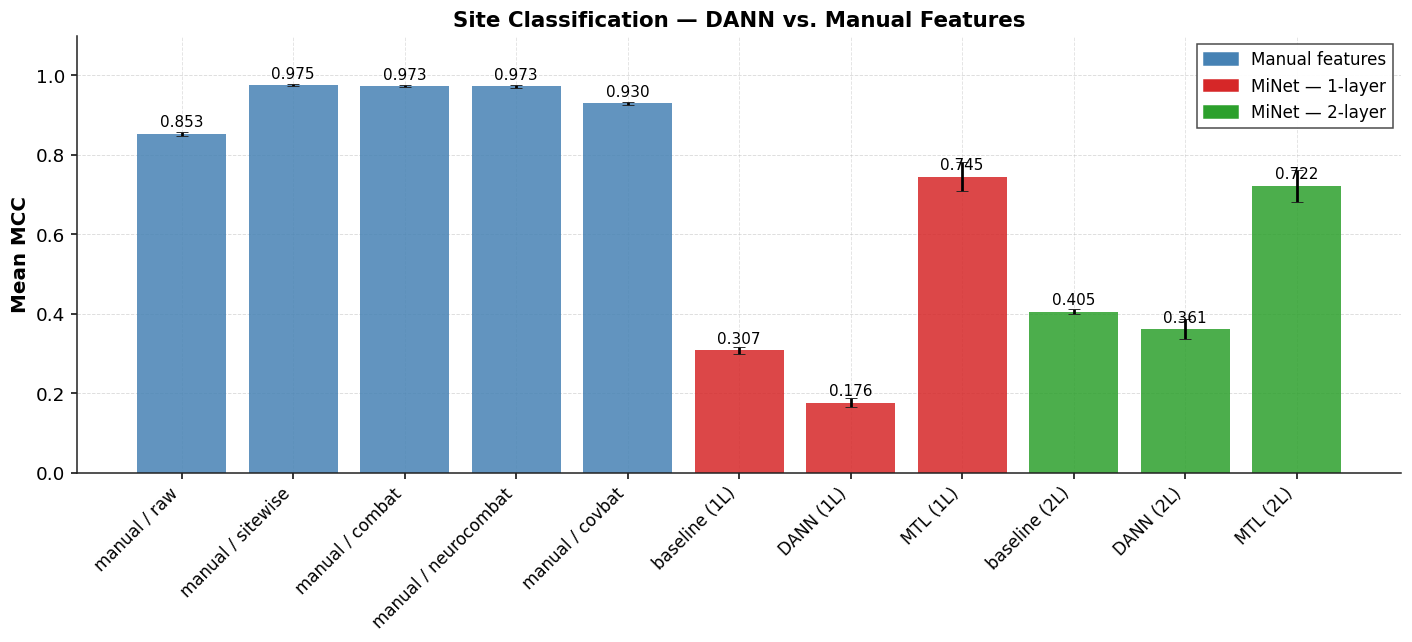

In [5]:
fig, ax = plt.subplots(figsize=(13, 6))

cs = comparison_site.copy()
labels = cs['label']
colors = [depth_color(t) for t in cs['tag']]

bars = ax.bar(range(len(cs)), cs['MCC_mean'], yerr=cs['MCC_std'],
              capsize=4, color=colors, alpha=0.85)

for i, (bar, val) in enumerate(zip(bars, cs['MCC_mean'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(range(len(cs)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=11)
ax.set_ylabel('Mean MCC', fontsize=13)
ax.set_title('Site Classification — DANN vs. Manual Features', fontsize=14)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)

# Legend: colour encodes feature family / extractor depth
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Manual features'),
                    Patch(color='#d62728', label='MiNet — 1-layer'),
                    Patch(color='#2ca02c', label='MiNet — 2-layer')],
          fontsize=11)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_dann_vs_manual.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Pathology Classification — DANN vs. Manual Features

In [6]:
manual_cb_patho = manual_patho[manual_patho['model'] == 'catboost']
dann_patho_raw  = dann_patho[dann_patho['method'] == 'raw']

rows = []
for method in METHODS:
    mdf = manual_cb_patho[manual_cb_patho['method'] == method]
    if not mdf.empty:
        rows.append({
            'features': 'manual',
            'tag': f'manual/{method}',
            'label': f'manual / {method}',
            'method': method,
            'AUC_mean': mdf['auc'].mean(),
            'AUC_std': mdf['auc'].std(),
            'MCC_mean': mdf['mcc'].mean(),
            'MCC_std': mdf['mcc'].std()
        })

# DANN — both 1-layer and 2-layer extractor depths
for tag_val in [t for t in DANN_TAG_ORDER if t in dann_patho_raw['tag'].unique()]:
    tdf = dann_patho_raw[dann_patho_raw['tag'] == tag_val]
    rows.append({
        'features': 'dann',
        'tag': tag_val,
        'label': TAG_LABEL.get(tag_val, tag_val),
        'method': 'raw',
        'AUC_mean': tdf['auc'].mean(),
        'AUC_std': tdf['auc'].std(),
        'MCC_mean': tdf['mcc'].mean(),
        'MCC_std': tdf['mcc'].std()
    })

comparison_patho = pd.DataFrame(rows)
print(comparison_patho.to_string(index=False))
comparison_patho.to_csv(f'{TABLES_DIR}/patho_comparison_dann_vs_manual.csv', index=False)

features                tag                label      method  AUC_mean  AUC_std  MCC_mean  MCC_std
  manual         manual/raw         manual / raw         raw  0.803402 0.047940  0.413149 0.097623
  manual    manual/sitewise    manual / sitewise    sitewise  0.801732 0.050882  0.415432 0.105195
  manual      manual/combat      manual / combat      combat  0.807803 0.051462  0.428845 0.107351
  manual manual/neurocombat manual / neurocombat neurocombat  0.808061 0.051413  0.430178 0.109484
  manual      manual/covbat      manual / covbat      covbat  0.792748 0.050983  0.408489 0.102870
    dann           baseline        baseline (1L)         raw  0.802671 0.050545  0.449374 0.106429
    dann               dann            DANN (1L)         raw  0.795972 0.054852  0.459870 0.107130
    dann                mtl             MTL (1L)         raw  0.750008 0.049880  0.341521 0.094268
    dann    baseline_2layer        baseline (2L)         raw  0.791972 0.048513  0.422359 0.101674
    dann  

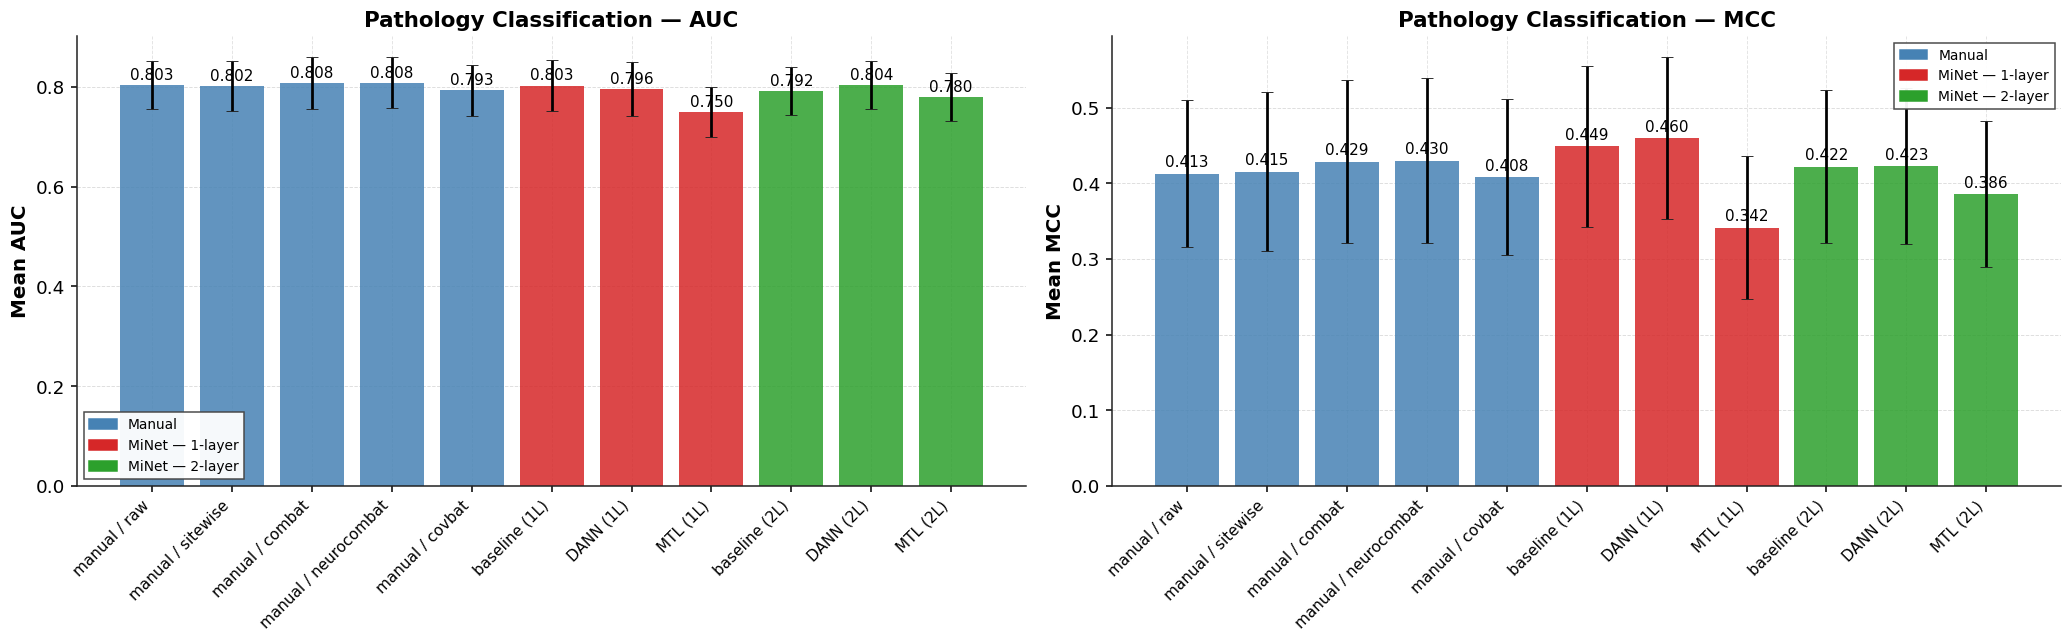

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

cp = comparison_patho.copy()
labels = cp['label']
colors = [depth_color(t) for t in cp['tag']]

for ax, metric, metric_col in zip(axes, ['AUC', 'MCC'], ['AUC_mean', 'MCC_mean']):
    std_col = metric_col.replace('mean', 'std')
    bars = ax.bar(range(len(cp)), cp[metric_col], yerr=cp[std_col],
                  capsize=4, color=colors, alpha=0.85)

    for bar, val in zip(bars, cp[metric_col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

    ax.set_xticks(range(len(cp)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.set_ylabel(f'Mean {metric}', fontsize=13)
    ax.set_title(f'Pathology Classification — {metric}', fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='steelblue', label='Manual'),
                        Patch(color='#d62728', label='MiNet — 1-layer'),
                        Patch(color='#2ca02c', label='MiNet — 2-layer')],
              fontsize=9)

fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/patho_dann_vs_manual.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Hospital Pathology AUC — DANN vs. Manual (raw)

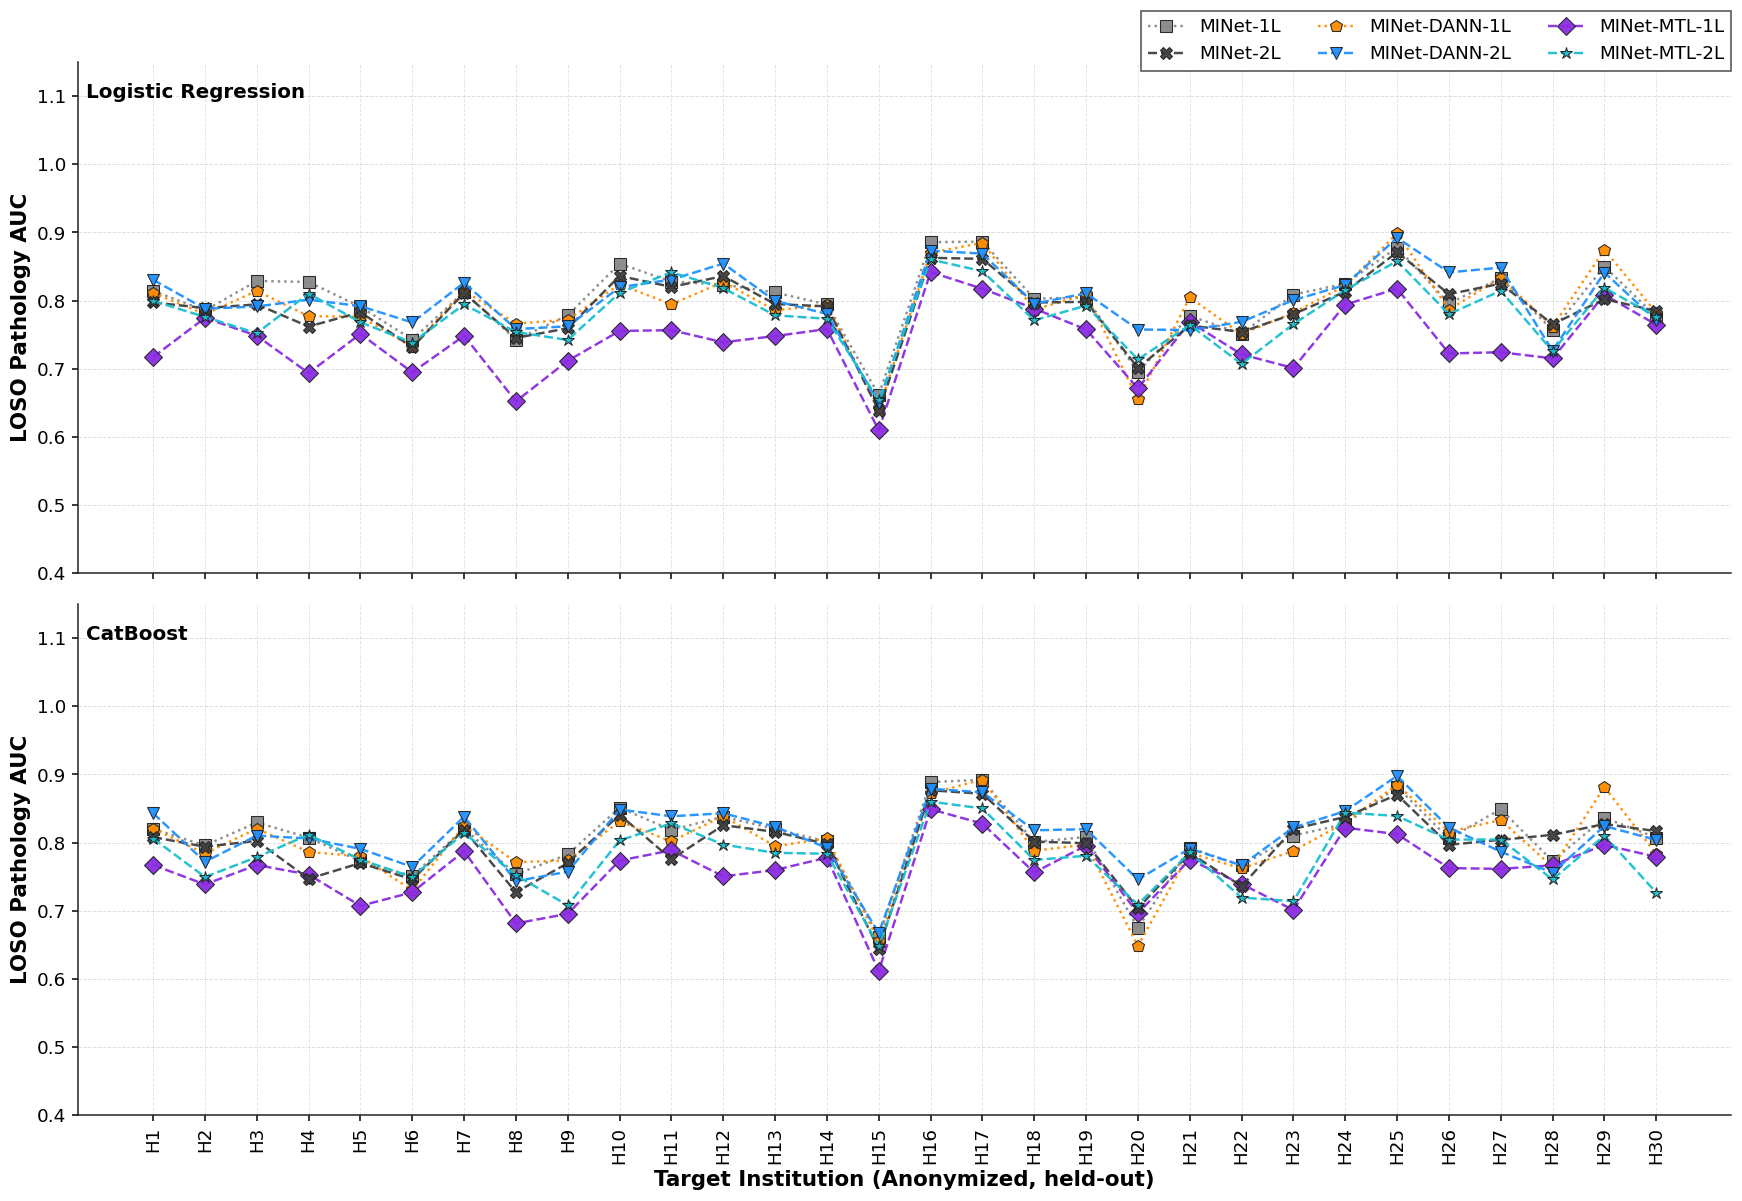

In [8]:
from src.visualization.style import legend_kwargs

manual_raw_patho = manual_cb_patho[manual_cb_patho['method'] == 'raw']
manual_hosp = manual_raw_patho.groupby('hospital')['auc'].mean()
all_hosp = sorted(manual_hosp.index, key=natural_sort_key)

# Two stacked panels: Logistic Regression (top) and CatBoost (bottom), each in
# the house style (distinct colour + marker per series, MINet-* legend names).
LEGEND_TAG_ORDER = ['baseline', 'baseline_2layer', 'dann', 'dann_2layer', 'mtl', 'mtl_2layer']
MODEL_PANELS = [('logreg', 'Logistic Regression'), ('catboost', 'CatBoost')]

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
handles = {}
for ax, (model, model_name) in zip(axes, MODEL_PANELS):
    for tag in [t for t in DANN_TAG_ORDER if t in dann_patho_raw['tag'].unique()]:
        sub = dann_patho_raw[(dann_patho_raw['tag'] == tag) & (dann_patho_raw['model'] == model)]
        vals = sub.groupby('hospital')['auc'].mean().reindex(all_hosp)
        handles[tag] = ax.errorbar(all_hosp, vals.values, yerr=None,
                                   label=HOSP_LABEL.get(tag, tag), **hosp_style(tag))
    ax.set_ylabel('LOSO Pathology AUC')
    ax.set_ylim(0.4, 1.15)
    ax.set_yticks(np.arange(0.4, 1.15, 0.1))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.text(0.005, 0.96, model_name, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top', ha='left')

axes[-1].set_xlabel('Target Institution (Anonymized, held-out)')
axes[-1].tick_params(axis='x', rotation=90)
leg_tags = [t for t in LEGEND_TAG_ORDER if t in handles]
axes[0].legend([handles[t] for t in leg_tags],
               [HOSP_LABEL.get(t, t) for t in leg_tags],
               **legend_kwargs(ncol=3))
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/patho_auc_per_hospital_dann_vs_manual.png',
            dpi=200, bbox_inches='tight')
plt.show()


## 4. Per-Hospital Site MCC — DANN vs. Manual (raw)

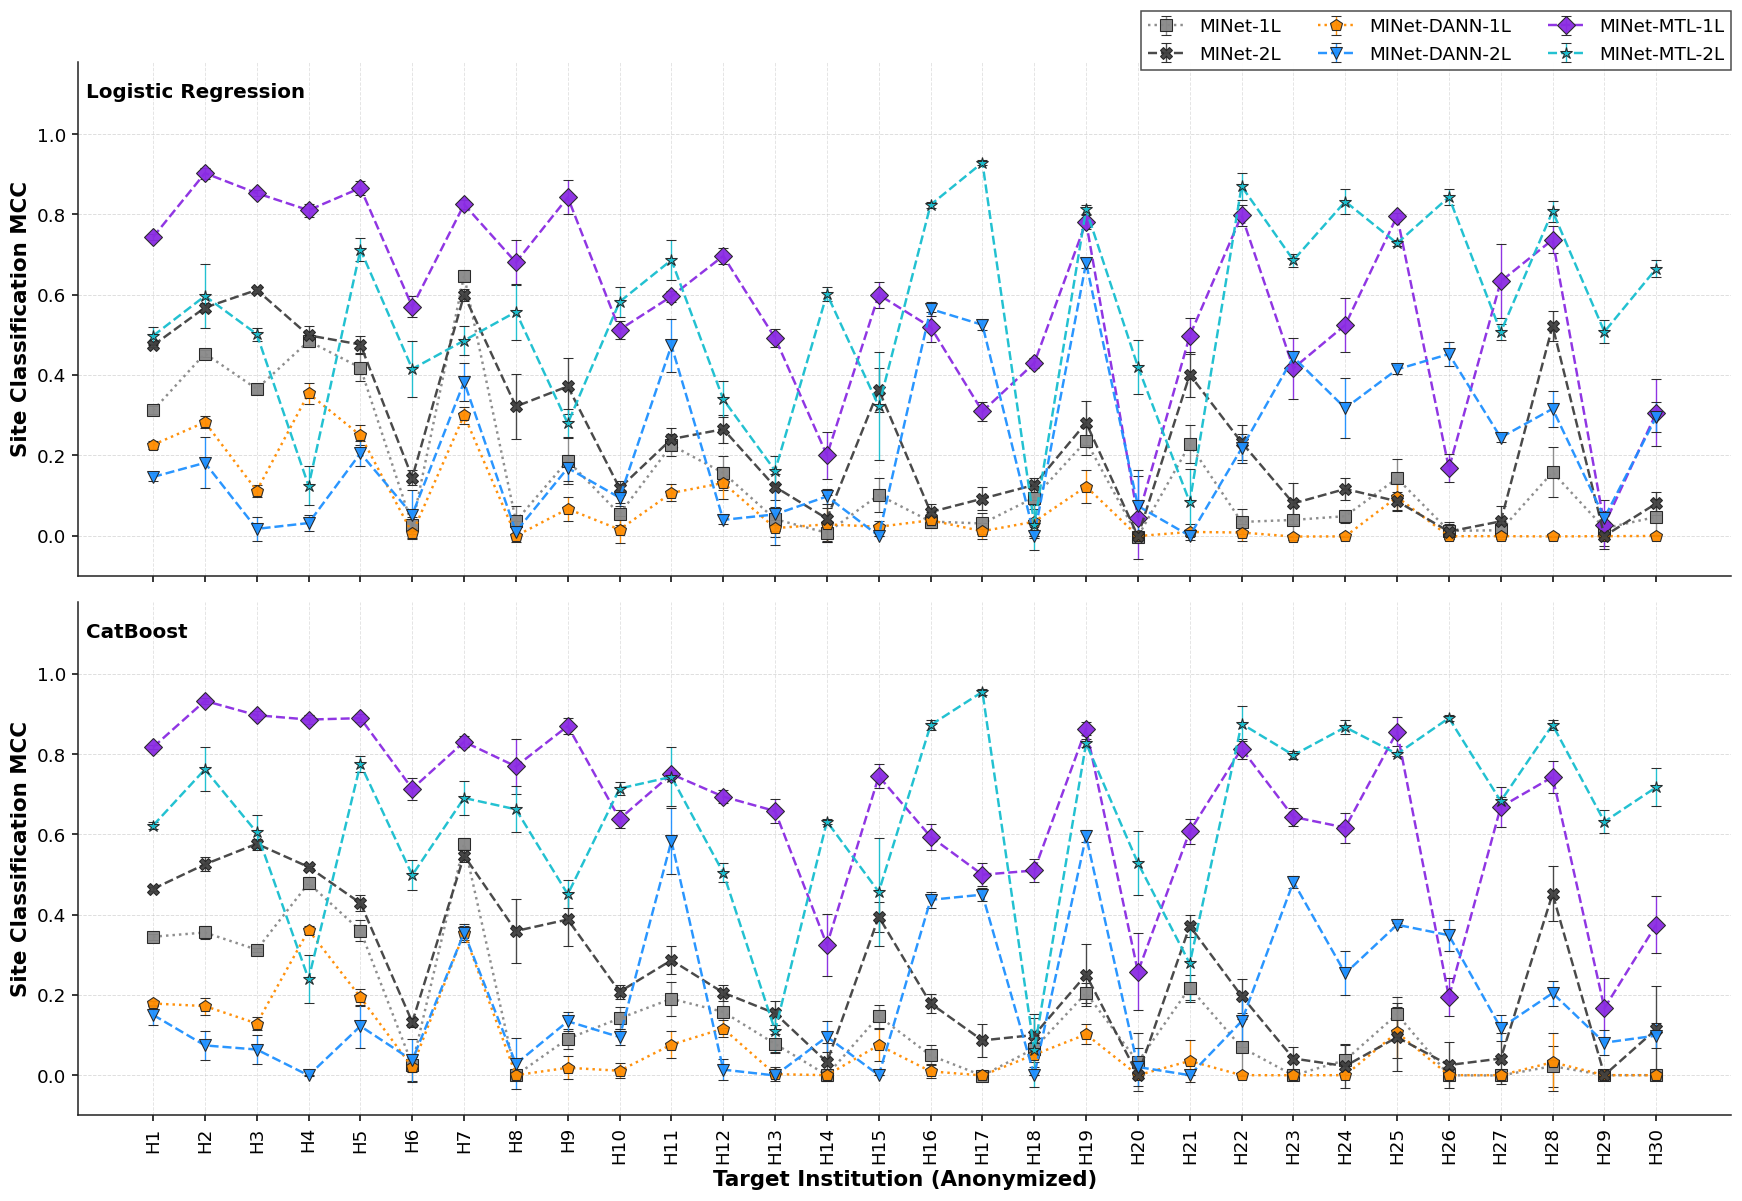

In [9]:
hospital_cols = sorted(
    [c for c in manual_raw.columns if c.startswith('mcc_H')],
    key=lambda c: natural_sort_key(c.replace('mcc_', ''))
)
sorted_hosp = [c.replace('mcc_', '') for c in hospital_cols]

# Two stacked panels: Logistic Regression (top) and CatBoost (bottom). The
# per-institution gap between the linear (LR) and nonlinear (CatBoost) probe is
# the two-classifier site signature.
LEGEND_TAG_ORDER = ['baseline', 'baseline_2layer', 'dann', 'dann_2layer', 'mtl', 'mtl_2layer']
MODEL_PANELS = [('logreg', 'Logistic Regression'), ('catboost', 'CatBoost')]

fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
handles = {}
for ax, (model, model_name) in zip(axes, MODEL_PANELS):
    for tag in [t for t in DANN_TAG_ORDER if t in dann_raw['tag'].unique()]:
        sub = dann_raw[(dann_raw['tag'] == tag) & (dann_raw['model'] == model)]
        means = sub[hospital_cols].mean().values
        sds   = sub[hospital_cols].std().values
        handles[tag] = ax.errorbar(sorted_hosp, means, yerr=sds,
                                   label=HOSP_LABEL.get(tag, tag), **hosp_style(tag))
    ax.set_ylabel('Site Classification MCC')
    ax.set_ylim(-0.1, 1.18)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.text(0.005, 0.96, model_name, transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top', ha='left')

axes[-1].set_xlabel('Target Institution (Anonymized)')
axes[-1].tick_params(axis='x', rotation=90)
leg_tags = [t for t in LEGEND_TAG_ORDER if t in handles]
axes[0].legend([handles[t] for t in leg_tags],
               [HOSP_LABEL.get(t, t) for t in leg_tags],
               **legend_kwargs(ncol=3))
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/site_mcc_per_hospital_dann_vs_manual.png',
            dpi=200, bbox_inches='tight')
plt.show()


## 5. Dual-Metric Summary — Site MCC vs. Pathology AUC

In [10]:
# Build a summary: for each approach, plot (site MCC, pathology AUC)
# Lower site MCC + higher patho AUC = better

rows = []

# Manual features — each harmonization method
manual_cb_site = manual_site[manual_site['model'] == 'catboost']
for method in METHODS:
    site_mcc = manual_cb_site[manual_cb_site['method'] == method]['mcc_overall'].mean()
    patho_auc = manual_cb_patho[manual_cb_patho['method'] == method]['auc'].mean()
    if not np.isnan(site_mcc) and not np.isnan(patho_auc):
        rows.append({'label': f'manual/{method}', 'tag': f'manual/{method}',
                     'site_mcc': site_mcc, 'patho_auc': patho_auc, 'group': 'manual'})

# DANN features — both 1-layer and 2-layer extractor depths
for tag_val in [t for t in DANN_TAG_ORDER if t in dann_site['tag'].unique()]:
    site_mcc = dann_site[dann_site['tag'] == tag_val]['mcc_overall'].mean()
    patho_sub = dann_patho[dann_patho['tag'] == tag_val] if tag_val in dann_patho['tag'].values else dann_patho
    patho_auc = patho_sub['auc'].mean()
    rows.append({'label': TAG_LABEL.get(tag_val, tag_val), 'tag': tag_val,
                 'site_mcc': site_mcc, 'patho_auc': patho_auc, 'group': 'dann'})

dual = pd.DataFrame(rows)
print(dual.to_string(index=False))
dual.to_csv(f'{TABLES_DIR}/dual_metric_summary.csv', index=False)

             label                tag  site_mcc  patho_auc  group
        manual/raw         manual/raw  0.852502   0.803402 manual
   manual/sitewise    manual/sitewise  0.975332   0.801732 manual
     manual/combat      manual/combat  0.973279   0.807803 manual
manual/neurocombat manual/neurocombat  0.972783   0.808061 manual
     manual/covbat      manual/covbat  0.929612   0.792748 manual
     baseline (1L)           baseline  0.307458   0.802671   dann
         DANN (1L)               dann  0.176335   0.795972   dann
          MTL (1L)                mtl  0.745367   0.750008   dann
     baseline (2L)    baseline_2layer  0.404883   0.791972   dann
         DANN (2L)        dann_2layer  0.361304   0.803634   dann
          MTL (2L)         mtl_2layer  0.721979   0.779594   dann


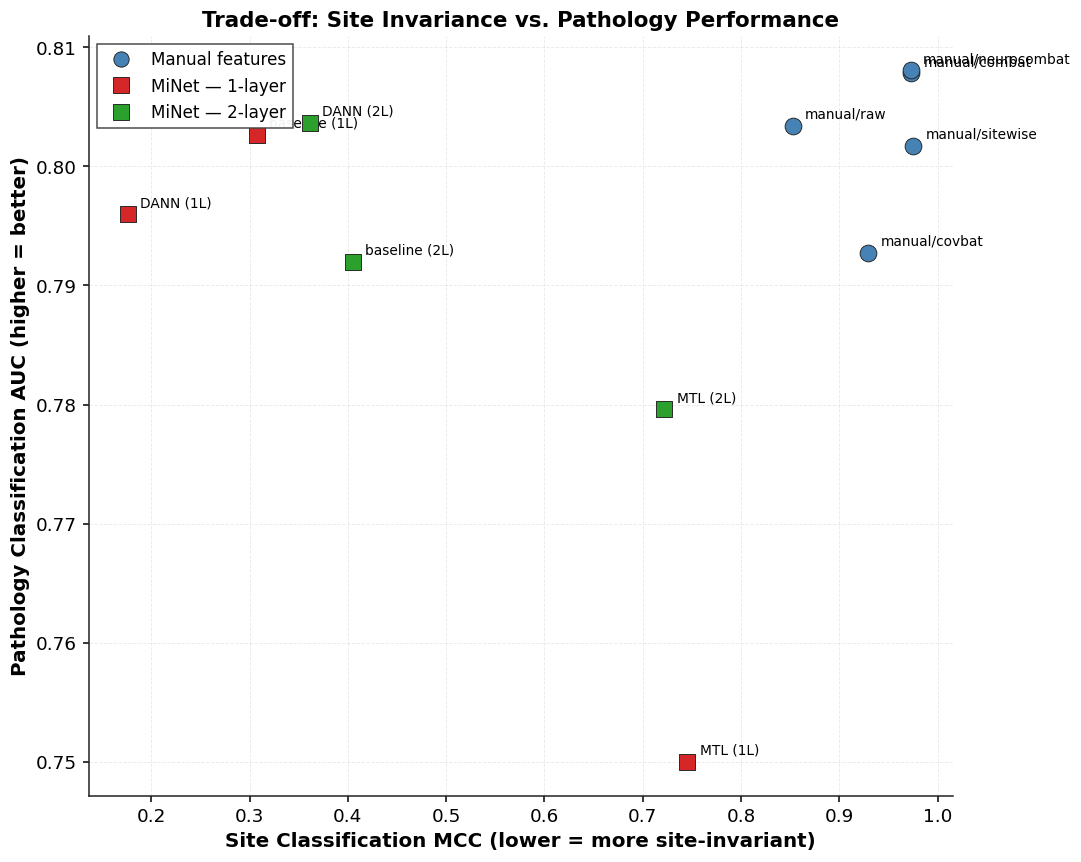

In [11]:
if len(dual) > 0:
    fig, ax = plt.subplots(figsize=(10, 8))

    for _, row in dual.iterrows():
        # marker = feature family (manual vs DANN); colour = extractor depth
        color = depth_color(row['tag'])
        marker = 'o' if row['group'] == 'manual' else 's'
        ax.scatter(row['site_mcc'], row['patho_auc'],
                   color=color, marker=marker, s=120, zorder=3,
                   edgecolor='#222222', linewidth=0.6)
        ax.annotate(row['label'], (row['site_mcc'], row['patho_auc']),
                    textcoords='offset points', xytext=(8, 5), fontsize=9)

    ax.set_xlabel('Site Classification MCC (lower = more site-invariant)', fontsize=13)
    ax.set_ylabel('Pathology Classification AUC (higher = better)', fontsize=13)
    ax.set_title('Trade-off: Site Invariance vs. Pathology Performance', fontsize=14)
    ax.grid(alpha=0.3)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
               markersize=10, label='Manual features'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#d62728',
               markersize=10, label='MiNet — 1-layer'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#2ca02c',
               markersize=10, label='MiNet — 2-layer'),
    ]
    ax.legend(handles=legend_elements, fontsize=11, loc='upper left')

    fig.tight_layout()
    fig.savefig(f'{FIGURES_DIR}/tradeoff_site_vs_patho.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. 2-Layer vs 1-Layer DANN — Is the New Extractor Worth It?

Direct comparison between the original 1-layer feature extraction (tags `baseline`, `dann`, `mtl`) and the 2-layer extraction (tags `baseline_2layer`, `dann_2layer`, `mtl_2layer`). All three training variants — the un-adversarial baseline, MTL, and DANN — were re-extracted at 2 layers, so the depth effect can be read off the **baseline as well**, isolating how much of any change is due to the deeper backbone itself versus the adversarial/multi-task objective.

Goal: quantify whether the 2-layer training is more or less effective at (i) suppressing site information in extracted features and (ii) preserving zero-shot diagnostic accuracy — and whether the baseline alone already captures most of the 1L→2L gain.

In [12]:
# 2L vs 1L delta tables and a side-by-side bar chart.
# Each pair is (1-layer tag, 2-layer tag) for the same training variant.
PAIRS = [('baseline', 'baseline_2layer'), ('dann', 'dann_2layer'), ('mtl', 'mtl_2layer')]
# Keep only pairs whose 2-layer tag is actually present (so the cell still runs
# before baseline_2layer has been computed).
PAIRS = [(v1, v2) for v1, v2 in PAIRS if v2 in set(dann_site['tag']) | set(dann_patho['tag'])]

rows = []
for v1, v2 in PAIRS:
    for model in ['catboost', 'logreg']:
        site_1 = dann_site[(dann_site.tag == v1) & (dann_site.model == model)]['mcc_overall']
        site_2 = dann_site[(dann_site.tag == v2) & (dann_site.model == model)]['mcc_overall']
        patho_1 = dann_patho[(dann_patho.tag == v1) & (dann_patho.model == model)]
        patho_2 = dann_patho[(dann_patho.tag == v2) & (dann_patho.model == model)]
        rows.append({
            'variant': v1, 'model': model,
            'site_mcc_1L': site_1.mean(), 'site_mcc_2L': site_2.mean(),
            'd_site_mcc': site_2.mean() - site_1.mean(),
            'patho_auc_1L': patho_1['auc'].mean(), 'patho_auc_2L': patho_2['auc'].mean(),
            'd_patho_auc': patho_2['auc'].mean() - patho_1['auc'].mean(),
            'patho_mcc_1L': patho_1['mcc'].mean(), 'patho_mcc_2L': patho_2['mcc'].mean(),
            'd_patho_mcc': patho_2['mcc'].mean() - patho_1['mcc'].mean(),
        })

delta = pd.DataFrame(rows).round(4)
print(delta.to_string(index=False))
delta.to_csv(f'{TABLES_DIR}/dann_2layer_vs_1layer_delta.csv', index=False)
print(f'\n  saved {TABLES_DIR}/dann_2layer_vs_1layer_delta.csv')

 variant    model  site_mcc_1L  site_mcc_2L  d_site_mcc  patho_auc_1L  patho_auc_2L  d_patho_auc  patho_mcc_1L  patho_mcc_2L  d_patho_mcc
baseline catboost       0.2996       0.3997      0.1001        0.8046        0.7947      -0.0099        0.4458        0.4248      -0.0210
baseline   logreg       0.3153       0.4101      0.0948        0.8007        0.7892      -0.0115        0.4530        0.4199      -0.0331
    dann catboost       0.1653       0.3374      0.1721        0.7982        0.8064       0.0082        0.4577        0.4316      -0.0261
    dann   logreg       0.1873       0.3852      0.1979        0.7937        0.8009       0.0071        0.4620        0.4149      -0.0471
     mtl catboost       0.7791       0.7594     -0.0197        0.7576        0.7786       0.0210        0.3464        0.3870       0.0406
     mtl   logreg       0.7116       0.6845     -0.0271        0.7424        0.7805       0.0382        0.3366        0.3849       0.0482

  saved results/tables/04_dann/da

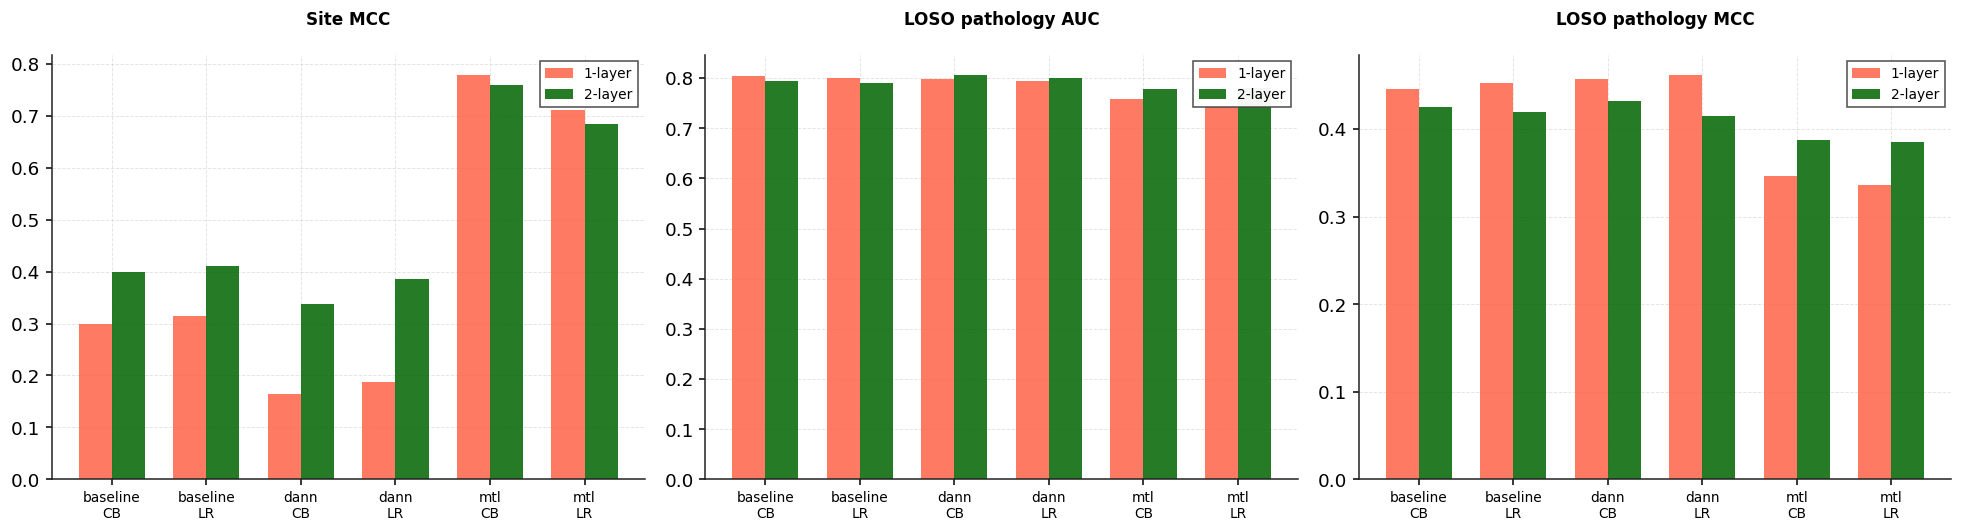

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('site_mcc', 'Site MCC'),
           ('patho_auc', 'LOSO pathology AUC'),
           ('patho_mcc', 'LOSO pathology MCC')]
x = np.arange(len(PAIRS) * 2)
width = 0.35

for ax, (metric, title) in zip(axes, metrics):
    keys_1L = [delta[(delta.variant == v) & (delta.model == m)][f'{metric}_1L'].iloc[0]
               for v, _ in PAIRS for m in ['catboost', 'logreg']]
    keys_2L = [delta[(delta.variant == v) & (delta.model == m)][f'{metric}_2L'].iloc[0]
               for v, _ in PAIRS for m in ['catboost', 'logreg']]
    labels = [f'{v}\n{m}' for v, _ in PAIRS for m in ['CB', 'LR']]
    ax.bar(x - width/2, keys_1L, width, label='1-layer', color='tomato', alpha=0.85)
    ax.bar(x + width/2, keys_2L, width, label='2-layer', color='darkgreen', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(f'{title}\n', fontsize=11)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/dann_2layer_vs_1layer.png', dpi=200, bbox_inches='tight')
plt.show()

## Conclusions

*(Fill in after running)*